<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB9(7).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [ ]:
# Download YOLOv3 config
!wget -q "https://raw.githubusercontent.com/pjreddie/darknet/master/cfg/yolov3.cfg" \
     -O "yolov3.cfg"

# Download COCO class names
!wget -q "https://raw.githubusercontent.com/pjreddie/darknet/master/data/coco.names" \
     -O "coco.names"

# Download YOLOv3 weights (236MB — takes ~1 min)
!wget -q "https://pjreddie.com/media/files/yolov3.weights" \
     -O "yolov3.weights"

# Verify
for f in ["yolov3.cfg", "coco.names", "yolov3.weights"]:
    size = os.path.getsize(f)
    print(f"{f}: {size:,} bytes", "✓" if size > 1000 else "✗ FAILED")

yolov3.cfg: 8,342 bytes ✓
coco.names: 625 bytes ✗ FAILED
yolov3.weights: 248,007,048 bytes ✓


In [ ]:
# Load class names
with open("coco.names", "r") as f:
    CLASSES = [line.strip() for line in f.readlines()]

# Load YOLO network
net = cv2.dnn.readNetFromDarknet("yolov3.cfg", "yolov3.weights")
net.setPreferableBackend(cv2.dnn.DNN_BACKEND_OPENCV)
net.setPreferableTarget(cv2.dnn.DNN_TARGET_CPU)

# Get output layer names
layer_names   = net.getLayerNames()
output_layers = [layer_names[i - 1] for i in net.getUnconnectedOutLayers().flatten()]

print("YOLO loaded!")
print(f"Detects {len(CLASSES)} classes including: car, truck, bus, motorbike")

YOLO loaded!
Detects 80 classes including: car, truck, bus, motorbike


Upload your parking lot image (aerial or street-level)


Saving parking-lot-7.jpg to parking-lot-7.jpg


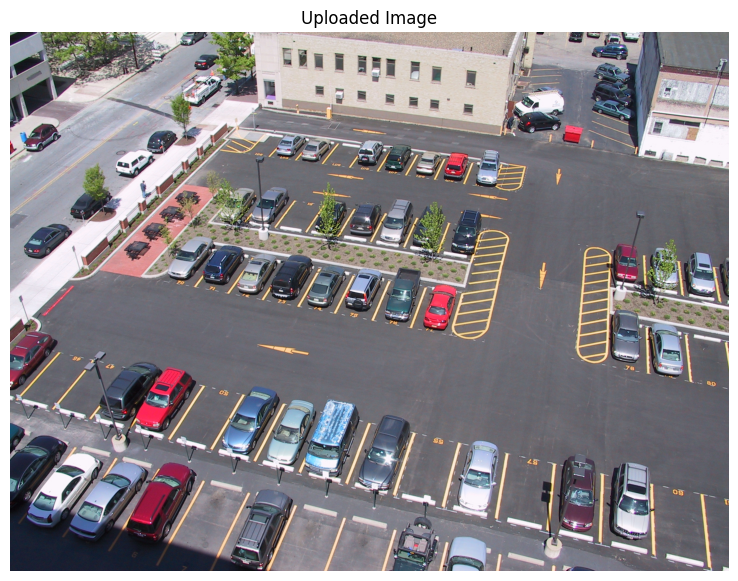

Image shape: (1536, 2048, 3)


In [ ]:
from google.colab import files

print("Upload your parking lot image (aerial or street-level)")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

img     = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(img_rgb)
plt.title("Uploaded Image")
plt.axis('off')
plt.show()
print("Image shape:", img.shape)

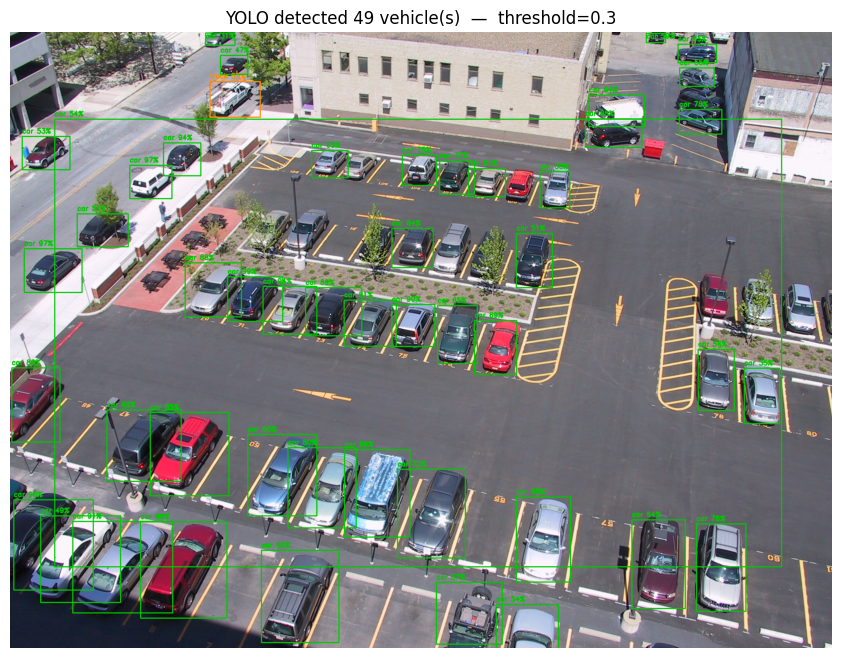

Total vehicles detected: 49


In [ ]:
def detect_yolo(image_path, confidence_threshold=0.3, nms_threshold=0.4):

    img     = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    (H, W)  = img.shape[:2]

    # Prepare image blob for YOLO
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (416, 416),
                                  swapRB=True, crop=False)
    net.setInput(blob)
    outputs = net.forward(output_layers)

    boxes, confidences, class_ids = [], [], []
    vehicle_classes = ["car", "truck", "bus", "motorbike", "bicycle"]

    # Parse all detections
    for output in outputs:
        for detection in output:
            scores     = detection[5:]
            class_id   = int(np.argmax(scores))
            confidence = float(scores[class_id])
            label      = CLASSES[class_id]

            if confidence > confidence_threshold and label in vehicle_classes:
                # YOLO returns center x,y and width,height (normalized)
                cx, cy = int(detection[0] * W), int(detection[1] * H)
                bw, bh = int(detection[2] * W), int(detection[3] * H)
                x1     = int(cx - bw / 2)
                y1     = int(cy - bh / 2)

                boxes.append([x1, y1, bw, bh])
                confidences.append(confidence)
                class_ids.append(class_id)

    # Non-Maximum Suppression — remove duplicate boxes
    indices = cv2.dnn.NMSBoxes(boxes, confidences,
                                confidence_threshold, nms_threshold)

    result = img_rgb.copy()
    count  = 0

    color_map = {
        "car":        (0,   200,  0),
        "truck":      (255, 140,  0),
        "bus":        (0,   120, 255),
        "motorbike":  (255, 0,   200),
        "bicycle":    (255, 220,  0),
    }

    if len(indices) > 0:
        for i in indices.flatten():
            x1, y1, bw, bh = boxes[i]
            x2, y2 = x1 + bw, y1 + bh
            label  = CLASSES[class_ids[i]]
            conf   = confidences[i]
            color  = color_map.get(label, (0, 200, 0))

            cv2.rectangle(result, (x1, y1), (x2, y2), color, 2)
            cv2.putText(result,
                        f"{label} {conf:.0%}",
                        (x1, max(y1 - 8, 15)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.55, color, 2)
            count += 1

    plt.figure(figsize=(12, 8))
    plt.imshow(result)
    plt.title(f"YOLO detected {count} vehicle(s)  —  threshold={confidence_threshold}")
    plt.axis('off')
    plt.show()
    print(f"Total vehicles detected: {count}")

# Run detection
detect_yolo(filename, confidence_threshold=0.3)